# 03a — Deterministic Individual Simulation

Calculate deterministic lifetime retirement values under High-Three
and BRS for each profile and separation scenario.

**TSP modeling:** Member contributes 5% under both systems.
BRS adds government contributions: 1% automatic from entry, plus
up to 4% matching beginning after 2 years of service, so the BRS
total is 6% in YOS 1–2 and 10% from YOS 3. High-Three total stays
at 5%. The comparison isolates what the government provides
differently.

**Dollar convention:** basic pay grows at the COLA rate (military
raises are assumed to track inflation), making the model internally
consistent in nominal terms; all reported values are then deflated
by the price level at separation and expressed in **constant 2026
dollars**.

**Fixed assumptions:** pay growth = COLA = 2.75% (DoD actuarial);
TSP returns = glide-path L Fund historical means; life expectancy =
SSA 2022 male expected total age.

**Inputs:** `data/processed/pay_profiles.csv`,
`data/processed/tsp_returns.csv`,
`data/processed/life_expectancy.csv`
**Output:** `data/processed/deterministic_results.csv`


In [61]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

sys.path.insert(0, str(Path("../src")))
from pension_calcs import (  # noqa: E402
    annual_pension_brs,
    annual_pension_high3,
    high_three_base,
)
from tsp_calcs import (  # noqa: E402
    BRS_CONTRIB_RATE,
    brs_total_rate,
    H3_MEMBER_RATE,
    _GLIDE_PATH,
    compute_fund_means,
    tsp_at_separation,
    tsp_grow_to_60,
)
from utils import npv_pension, pv_lump_sum  # noqa: E402

PROCESSED = Path("../data/processed")

## Model constants

In [62]:
PROFILES = ["Officer", "Enlisted", "PriorEnlistedOfficer"]
# Display order for cross-profile tables and charts
PROFILE_ORDER = [
    "Enlisted", "PriorEnlistedOfficer", "Officer"
]
PROFILE_SCENARIOS = {
    "Officer": list(range(4, 41, 2)),
    "Enlisted": list(range(4, 31, 2)),
    "PriorEnlistedOfficer": list(range(4, 41, 2)),
}
ENTRY_AGE = {
    "Officer": 22,
    "Enlisted": 18,
    "PriorEnlistedOfficer": 18,
}

COLA_RATE = 0.0275      # DoD Board of Actuaries long-term
PAY_GROWTH = COLA_RATE  # basic pay raises assumed to track COLA
DISCOUNT_RATE = 0.05    # Nominal rate for NPV calculations

print(
    f"BRS contribution: {BRS_CONTRIB_RATE:.0%} total from YOS 3"
    " (member 5% + govt 1% auto + 4% match);"
)
print(
    "                  6% in YOS 1-2"
    " (match starts after 2 years)"
)
print(
    f"H3  contribution: {H3_MEMBER_RATE:.0%}"
    " (member 5% only)"
)
print("Reporting units:  constant 2026 dollars")


BRS contribution: 10% total from YOS 3 (member 5% + govt 1% auto + 4% match);
                  6% in YOS 1-2 (match starts after 2 years)
H3  contribution: 5% (member 5% only)
Reporting units:  constant 2026 dollars


## Load data

In [63]:
pay_profiles = pd.read_csv(PROCESSED / "pay_profiles.csv")
tsp_returns = pd.read_csv(PROCESSED / "tsp_returns.csv")
life_exp = pd.read_csv(PROCESSED / "life_expectancy.csv")

print(f"pay_profiles: {pay_profiles.shape}")
print(f"tsp_returns:  {tsp_returns.shape}")
print(f"life_exp:     {life_exp.shape}")

pay_profiles: (110, 3)
tsp_returns:  (39, 21)
life_exp:     (120, 5)


## TSP glide-path fund means

The glide path assigns each year's TSP return by years remaining
to age 60 (`_GLIDE_PATH` / `select_fund` in `src/tsp_calcs.py`),
emulating a participant who holds the target-date L Fund matching
their 60th birthday. The same rule applies during service and in
the growth-to-60 phase after separation; age 60+ drawdown uses
L Income. The means below are the fixed returns for the
deterministic scenario; notebook 03b draws from the full return
distributions.

**Data note:** L Fund return histories are extended back to 2002 via
synthetic reconstruction — regression weights (SLSQP, constrained to
sum to 1) fit on the overlapping period are applied to the five
underlying individual-fund returns (C, S, I, F, G). Only pre-inception
NaN values are backfilled; actual reported values are unchanged.
R² 0.989–0.998 across the four L Funds. L 2050 gains 10 additional
years (n: 14 → 24), correcting for selection bias from its 2012
inception missing the 2001–2002 bear market.

In [64]:
means = compute_fund_means(tsp_returns)

print("Glide path: fund held by years remaining to age 60")
hdr = "  {:<11} {:<9} {:<10} {:>6} {:>4}"
print(hdr.format("Yrs to 60", "Ages", "Fund", "Mean", "n"))
print("  " + "-" * 45)
prev = None
for thr, fund in _GLIDE_PATH:
    if prev is None:
        yrs, ages = f">= {thr}", f"<= {60 - thr}"
    else:
        hi = 60 - thr if thr > 0 else 59
        yrs = f"{thr}-{prev - 1}"
        ages = f"{60 - prev + 1}-{hi}"
    n = tsp_returns[fund].notna().sum()
    print(hdr.format(
        yrs, ages, fund, f"{means[fund]:.2%}", n
    ))
    prev = thr
print("  (age 60+ drawdown also uses L Income)")

Glide path: fund held by years remaining to age 60
  Yrs to 60   Ages      Fund         Mean    n
  ---------------------------------------------
  >= 30       <= 30     L 2050      9.47%   24
  20-29       31-40     L 2040      8.93%   24
  10-19       41-50     L 2030      8.09%   24
  0-9         51-59     L Income    4.80%   24
  (age 60+ drawdown also uses L Income)


## Officer, 20 YOS — step-by-step walkthrough

One scenario traced end to end before computing all 52: an
officer who enters at age 22, serves 20 years, and separates at
age 42. Lifetime value under each system is **pension NPV + TSP
present value**, stated as of the separation date in constant
2026 dollars.

Three rates appear below, each doing a different job:

- **COLA (2.75%)** — inflation. Grows nominal dollar amounts
  over time: basic pay during service, pension checks during
  retirement.
- **Discount rate (5%)** — time value of money. A payment N
  years after separation is divided by 1.05^N to state what it
  is worth at separation (money available sooner can be
  invested).
- **Deflator (1.0275^20 ≈ 1.72)** — unit conversion. Prices
  rise ~72% between 2026 and separation, so nominal values at
  separation are divided by 1.72 to express them in 2026
  dollars. Unlike discounting, this moves no value through
  time — it only changes units.

Both systems credit the member's own 5% TSP contribution; the
systems differ only in the government TSP contribution (BRS
only) and the pension multiplier (H3 2.5%/yr vs BRS 2.0%/yr).

In [65]:
DEMO_PROFILE = "Officer"
DEMO_YOS = 20
sep_age = ENTRY_AGE[DEMO_PROFILE] + DEMO_YOS

pay = pay_profiles.query(
    "Profile == @DEMO_PROFILE and YOS <= @DEMO_YOS"
).set_index("YOS")["MonthlyPay"]

# Nominal pay: the 2026 table grown at COLA, i.e.
#   pay_nom[yos] = pay_2026[yos] * 1.0275^(yos - 1)
pay_nom = pay * (1 + PAY_GROWTH) ** (
    pay.index.to_numpy() - 1
)
# Deflator: price level at separation relative to 2026.
# Divide nominal-at-separation values by this to restate
# them in 2026 dollars (unit conversion, not discounting).
DEFL = (1 + COLA_RATE) ** DEMO_YOS

# Pension base: average of the 36 highest-paid months
h3_base = high_three_base(pay_nom)

life_row = life_exp.loc[
    life_exp["Age"] == sep_age
].squeeze()
n_pension_yrs = life_row["MaleTotalAge"] - sep_age

print(f"Profile: {DEMO_PROFILE}, Sep YOS: {DEMO_YOS}")
print(
    f"Ages: enters {ENTRY_AGE[DEMO_PROFILE]},"
    f" separates {sep_age}"
)
print(
    f"\nDeflator to 2026 $: 1.0275^{DEMO_YOS}"
    f" = {DEFL:.3f}"
)
print("\nHigh-Three base (avg of 36 highest-paid months):")
print(
    f"  ${h3_base:,.2f}/mo nominal at separation"
    f"  =  ${h3_base / DEFL:,.2f}/mo in 2026 $"
)
print(
    f"\nExpected death age (SSA 2022 male, alive at"
    f" {sep_age}): {life_row['MaleTotalAge']:.1f}"
)
print(
    f"  -> pension paid for ~{n_pension_yrs:.1f} years"
)

Profile: Officer, Sep YOS: 20
Ages: enters 22, separates 42

Deflator to 2026 $: 1.0275^20 = 1.720

High-Three base (avg of 36 highest-paid months):
  $19,271.12/mo nominal at separation  =  $11,201.35/mo in 2026 $

Expected death age (SSA 2022 male, alive at 42): 77.9
  -> pension paid for ~35.9 years


In [66]:
# Accumulation: each service year,
#   balance = (balance + rate * annual pay) * (1 + r)
# where r is the glide-path fund mean for that age.
# BRS rate: 6% of pay in YOS 1-2, 10% from YOS 3
# (member 5% + govt 1% auto + 4% match).
# H3 rate: the member's 5% only.
tsp_sep_brs = tsp_at_separation(
    pay_nom, ENTRY_AGE[DEMO_PROFILE], means, brs_total_rate
)
tsp_sep_h3 = tsp_at_separation(
    pay_nom, ENTRY_AGE[DEMO_PROFILE], means, H3_MEMBER_RATE
)

# Separation (42) to age 60: no further contributions;
# the balance keeps compounding on the glide path
gap_yrs = 60 - sep_age
tsp_60_brs = tsp_grow_to_60(tsp_sep_brs, sep_age, means)
tsp_60_h3 = tsp_grow_to_60(tsp_sep_h3, sep_age, means)

# Value the age-60 balance as of separation, in 2026 $:
#   / 1.05^18   discount (18 years of waiting)
#   / 1.720     deflate  (state in 2026 dollars)
tsp_pv_brs = pv_lump_sum(
    tsp_60_brs, gap_yrs, DISCOUNT_RATE
) / DEFL
tsp_pv_h3 = pv_lump_sum(
    tsp_60_h3, gap_yrs, DISCOUNT_RATE
) / DEFL

print("TSP balance at separation, age 42 (nominal):")
print(f"  BRS:             ${tsp_sep_brs:>12,.0f}")
print(f"  H3:              ${tsp_sep_h3:>12,.0f}")
print(
    f"\nTSP balance at age 60, after {gap_yrs} more"
    " years of growth (nominal):"
)
print(f"  BRS:             ${tsp_60_brs:>12,.0f}")
print(f"  H3:              ${tsp_60_h3:>12,.0f}")
print(
    f"\nTSP PV = balance at 60"
    f" / 1.05^{gap_yrs} / {DEFL:.3f}:"
)
print(f"  BRS:             ${tsp_pv_brs:>12,.0f}")
print(f"  H3:              ${tsp_pv_h3:>12,.0f}")
print(
    f"  Govt portion:    "
    f"${tsp_pv_brs - tsp_pv_h3:>12,.0f}  (BRS-only)"
)

TSP balance at separation, age 42 (nominal):
  BRS:             $     644,298
  H3:              $     334,907

TSP balance at age 60, after 18 more years of growth (nominal):
  BRS:             $   1,978,496
  H3:              $   1,028,425

TSP PV = balance at 60 / 1.05^18 / 1.720:
  BRS:             $     477,849
  H3:              $     248,387
  Govt portion:    $     229,463  (BRS-only)


In [67]:
# Annual pension (nominal at separation):
#   base * 12 months * multiplier-per-year * YOS
#   H3:  2.5%/yr * 20 YOS = 50% of base
#   BRS: 2.0%/yr * 20 YOS = 40% of base
h3_annual = annual_pension_high3(h3_base, DEMO_YOS)
brs_annual = annual_pension_brs(h3_base, DEMO_YOS)

# Pension NPV: checks grow with COLA but are discounted,
# so the check t years after separation is worth
#   annual * (1.0275 / 1.05)^t      (~2.2% real discount)
# Summed over the ~35.9 expected pension years, then
# deflated to 2026 dollars.
h3_npv = npv_pension(
    h3_annual, COLA_RATE, DISCOUNT_RATE, n_pension_yrs
) / DEFL
brs_npv = npv_pension(
    brs_annual, COLA_RATE, DISCOUNT_RATE, n_pension_yrs
) / DEFL

h3_total = h3_npv + tsp_pv_h3
brs_total = brs_npv + tsp_pv_brs
diff = brs_total - h3_total

print(
    "Annual pension = base * 12 * multiplier * YOS"
    " (nominal):"
)
print(
    f"  H3:  ${h3_base:,.0f} * 12 * 2.5% * {DEMO_YOS}"
    f" = ${h3_annual:>9,.0f}  (50% of base pay)"
)
print(
    f"  BRS: ${h3_base:,.0f} * 12 * 2.0% * {DEMO_YOS}"
    f" = ${brs_annual:>9,.0f}  (40% of base pay)"
)

W = 14
print(
    "\nLifetime retirement value"
    " (NPV at separation, constant 2026 $):"
)
print(f"  {'':30} {'High-Three':>{W}} {'BRS':>{W}}")
print("  " + "-" * (32 + W * 2))
print(
    f"  {'Pension NPV':30}"
    f" ${h3_npv:{W-1},.0f} ${brs_npv:{W-1},.0f}"
)
print(
    f"  {'Member TSP PV (5%)':30}"
    f" ${tsp_pv_h3:{W-1},.0f} ${tsp_pv_h3:{W-1},.0f}"
)
print(
    f"  {'Govt TSP PV (BRS only)':30}"
    f" {'—':>{W}} ${(tsp_pv_brs - tsp_pv_h3):{W-1},.0f}"
)
print("  " + "-" * (32 + W * 2))
print(
    f"  {'Total NPV':30}"
    f" ${h3_total:{W-1},.0f} ${brs_total:{W-1},.0f}"
)
sign = "+" if diff >= 0 else ""
print(f"\n  Difference (BRS - H3): {sign}${diff:,.0f}")
print(
    "\n  Read: the government TSP contribution adds"
    f" ${tsp_pv_brs - tsp_pv_h3:,.0f}, but the lower"
)
print(
    f"  pension multiplier reduces pension NPV by"
    f" ${h3_npv - brs_npv:,.0f} for this career."
)

Annual pension = base * 12 * multiplier * YOS (nominal):
  H3:  $19,271 * 12 * 2.5% * 20 = $  115,627  (50% of base pay)
  BRS: $19,271 * 12 * 2.0% * 20 = $   92,501  (40% of base pay)

Lifetime retirement value (NPV at separation, constant 2026 $):
                                     High-Three            BRS
  ------------------------------------------------------------
  Pension NPV                    $    1,696,172 $    1,356,938
  Member TSP PV (5%)             $      248,387 $      248,387
  Govt TSP PV (BRS only)                      — $      229,463
  ------------------------------------------------------------
  Total NPV                      $    1,944,559 $    1,834,787

  Difference (BRS - H3): $-109,772

  Read: the government TSP contribution adds $229,463, but the lower
  pension multiplier reduces pension NPV by $339,234 for this career.


## All profiles and scenarios

In [68]:
profile_max = (
    pay_profiles.groupby("Profile")["YOS"].max()
)


def calc_lifetime(profile, sep_yos):
    """Deterministic lifetime values, constant 2026 $."""
    if sep_yos > profile_max[profile]:
        return None
    sep_age = ENTRY_AGE[profile] + sep_yos
    pay = pay_profiles.query(
        "Profile == @profile and YOS <= @sep_yos"
    ).set_index("YOS")["MonthlyPay"]
    pay_nom = pay * (1 + PAY_GROWTH) ** (
        pay.index.to_numpy() - 1
    )
    defl = (1 + COLA_RATE) ** sep_yos

    h3_base = high_three_base(pay_nom)
    life_row = life_exp.loc[
        life_exp["Age"] == sep_age
    ].squeeze()
    n_pens = life_row["MaleTotalAge"] - sep_age

    gap = max(0, 60 - sep_age)
    tsp_pv_brs = pv_lump_sum(
        tsp_grow_to_60(
            tsp_at_separation(
                pay_nom, ENTRY_AGE[profile], means,
                brs_total_rate,
            ),
            sep_age, means,
        ),
        gap, DISCOUNT_RATE,
    ) / defl
    tsp_pv_h3 = pv_lump_sum(
        tsp_grow_to_60(
            tsp_at_separation(
                pay_nom, ENTRY_AGE[profile], means,
                H3_MEMBER_RATE,
            ),
            sep_age, means,
        ),
        gap, DISCOUNT_RATE,
    ) / defl

    if sep_yos >= 20:
        h3_ann = annual_pension_high3(h3_base, sep_yos)
        brs_ann = annual_pension_brs(h3_base, sep_yos)
        h3_npv = npv_pension(
            h3_ann, COLA_RATE, DISCOUNT_RATE, n_pens
        ) / defl
        brs_npv = npv_pension(
            brs_ann, COLA_RATE, DISCOUNT_RATE, n_pens
        ) / defl
    else:
        h3_ann = brs_ann = h3_npv = brs_npv = 0.0

    h3_total = h3_npv + tsp_pv_h3
    brs_total = brs_npv + tsp_pv_brs
    return {
        "Profile": profile,
        "SepYOS": sep_yos,
        "SepAge": sep_age,
        "H3Annual": h3_ann,
        "H3PensionNPV": h3_npv,
        "H3TSP_PV": tsp_pv_h3,
        "H3Total": h3_total,
        "BRSAnnual": brs_ann,
        "BRSPensionNPV": brs_npv,
        "BRS_TSP_PV": tsp_pv_brs,
        "BRSTotal": brs_total,
        "BRSAdv": brs_total - h3_total,
    }


In [69]:
rows = []
for profile in PROFILES:
    for sep_yos in PROFILE_SCENARIOS[profile]:
        row = calc_lifetime(profile, sep_yos)
        if row is not None:
            rows.append(row)

results = pd.DataFrame(rows)
print(f"{len(results)} scenarios computed.")

# Display whole dollars; `results` keeps full precision
money_cols = results.columns.drop(
    ["Profile", "SepYOS", "SepAge"]
)
results.head(10).style.format(
    "{:,.0f}", subset=list(money_cols)
)

52 scenarios computed.


,Profile,SepYOS,SepAge,H3Annual,H3PensionNPV,H3TSP_PV,H3Total,BRSAnnual,BRSPensionNPV,BRS_TSP_PV,BRSTotal,BRSAdv
0,Officer,4,26,0,0,"37,732","37,732",0,0,"62,083","62,083","24,351"
1,Officer,6,28,0,0,"60,842","60,842",0,0,"107,709","107,709","46,868"
2,Officer,8,30,0,0,"84,229","84,229",0,0,"153,865","153,865","69,636"
3,Officer,10,32,0,0,"108,984","108,984",0,0,"202,730","202,730","93,746"
4,Officer,12,34,0,0,"135,289","135,289",0,0,"254,664","254,664","119,375"
5,Officer,14,36,0,0,"162,061","162,061",0,0,"307,505","307,505","145,443"
6,Officer,16,38,0,0,"189,966","189,966",0,0,"362,579","362,579","172,613"
7,Officer,18,40,0,0,"218,999","218,999",0,0,"419,876","419,876","200,877"
8,Officer,20,42,"115,627","1,696,172","248,387","1,944,559","92,501","1,356,938","477,849","1,834,787","-109,772"
9,Officer,22,44,"144,753","1,945,657","279,730","2,225,387","115,802","1,556,526","539,698","2,096,223","-129,164"


## Results summary

Total NPV by system, profile, and separation YOS.
Values in constant 2026 \$ thousands. `H3Annual` / `BRSAnnual` are nominal at separation. Both systems credit the member's own 5%
TSP contribution; the difference reflects only government-funded
components (govt TSP contribution + pension multiplier).

In [70]:
def pivot_k(col):
    """Pivot results column to profile x YOS, 2026 $K."""
    pv = results.pivot(
        index="Profile", columns="SepYOS", values=col
    )
    return pv.reindex(PROFILE_ORDER) / 1000


# One decimal, blanks for scenarios beyond a profile's max
FMT = dict(float_format="{:,.1f}".format, na_rep="")

print("High-Three total NPV (2026 $ thousands):")
print(pivot_k("H3Total").to_string(**FMT))
print()
print("BRS total NPV (2026 $ thousands):")
print(pivot_k("BRSTotal").to_string(**FMT))
print()
print("Difference, BRS - H3 (2026 $ thousands)  [+ = BRS higher]:")
print(pivot_k("BRSAdv").to_string(**FMT))

High-Three total NPV (2026 $ thousands):
SepYOS                 4    6    8     10    12    14    16    18      20      22      24      26      28      30      32      34      36      38      40
Profile                                                                                                                                                  
Enlisted             24.3 38.3 53.0  68.6  84.5 101.9 119.6 138.6 1,205.3 1,458.1 1,671.7 1,836.4 1,986.5 2,096.6                                        
PriorEnlistedOfficer 24.3 38.3 53.0  73.7  97.7 123.6 149.6 176.7 1,805.9 1,943.2 2,182.3 2,529.0 2,648.3 2,955.5 3,447.8 3,539.4 3,742.5 4,050.7 4,340.4
Officer              37.7 60.8 84.2 109.0 135.3 162.1 190.0 219.0 1,944.6 2,225.4 2,601.8 2,816.4 3,120.3 3,452.6 3,808.1 3,997.9 4,064.2 4,112.2 4,137.9

BRS total NPV (2026 $ thousands):
SepYOS                 4     6     8     10    12    14    16    18      20      22      24      26      28      30      32      34      36      38      4

## Lifetime value comparison by career length

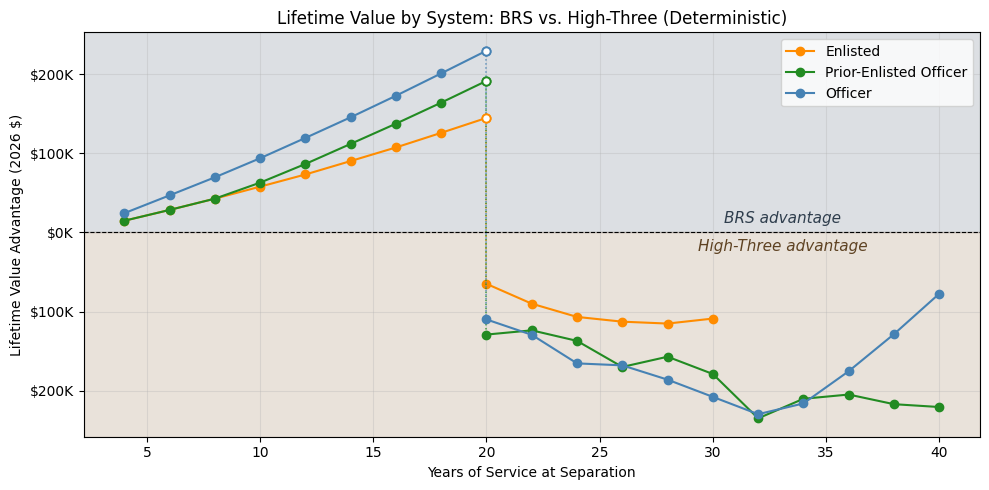

Key assumptions (deterministic baseline):
  Pay growth:         2.75%  (raises assumed to track COLA)
  COLA rate:          2.75%  (DoD Board of Actuaries long-term)
  Discount rate:      5.00%  (nominal NPV)
  TSP, BRS total:     10.00%  (YOS 3+; 6% in YOS 1-2)
  TSP, H3 total:      5.00%  (member 5% only)
  TSP returns:        glide-path L Fund historical means
  Life expectancy:    SSA 2022, male expected total age
  Reporting units:    constant 2026 dollars


In [71]:
profile_styles = {
    "Enlisted": ("darkorange", "Enlisted"),
    "PriorEnlistedOfficer": (
        "forestgreen", "Prior-Enlisted Officer"
    ),
    "Officer": ("steelblue", "Officer"),
}

fig, ax = plt.subplots(figsize=(10, 5))

# The pension vests *at* 20 YOS, so the difference jumps there —
# it is a discontinuity, not a slope. Draw each profile as a
# pre-cliff segment rising to its value on the cusp of vesting at
# 20 (the TSP-only difference, BRS_TSP - H3_TSP, which is what the
# whole pre-20 line already plots since pensions are zero on both
# sides below 20), shown as an OPEN marker = the left-limit not
# attained; a dotted vertical = the cliff itself; then the vested
# 20+ line.
for profile, (color, label) in profile_styles.items():
    sub = results[results["Profile"] == profile].sort_values(
        "SepYOS"
    )
    pre = sub[sub["SepYOS"] < 20]
    post = sub[sub["SepYOS"] >= 20]
    row20 = post.iloc[0]
    cusp20 = (
        row20["BRS_TSP_PV"] - row20["H3TSP_PV"]
    ) / 1000
    vested20 = row20["BRSAdv"] / 1000

    ax.plot(
        list(pre["SepYOS"]) + [20],
        list(pre["BRSAdv"] / 1000) + [cusp20],
        marker="o", color=color, label=label,
    )
    ax.plot(
        [20], [cusp20], marker="o", mfc="white",
        mec=color, mew=1.4, zorder=5,
    )
    ax.plot(
        [20, 20], [cusp20, vested20], ls=":",
        color=color, lw=1.1, alpha=0.8,
    )
    ax.plot(
        post["SepYOS"], post["BRSAdv"] / 1000,
        marker="o", color=color,
    )

ax.axhline(0, color="black", linewidth=0.8, linestyle="--")

# Light shading labels the two halves: above zero BRS advantage,
# below zero High-Three advantage. Muted slate / brown are kept
# clear of the orange/green/blue profile line colors. Labels sit
# just off the zero line (x in axes fraction, y in data via
# get_yaxis_transform; a small point offset lifts them clear).
ymin, ymax = ax.get_ylim()
ax.axhspan(0, ymax, color="#3f5266", alpha=0.18, zorder=0)
ax.axhspan(ymin, 0, color="#8a6033", alpha=0.18, zorder=0)
ax.set_ylim(ymin, ymax)
tx = ax.get_yaxis_transform()
ax.annotate(
    "BRS advantage", xy=(0.78, 0), xycoords=tx,
    xytext=(0, 5), textcoords="offset points",
    ha="center", va="bottom", fontsize=11, style="italic",
    color="#2f3e4d",
)
ax.annotate(
    "High-Three advantage", xy=(0.78, 0), xycoords=tx,
    xytext=(0, -5), textcoords="offset points",
    ha="center", va="top", fontsize=11, style="italic",
    color="#5e4222",
)

ax.set_xlabel("Years of Service at Separation")
# All-positive axis: tick magnitude is the size of the advantage;
# the shaded region/label says which system it favors.
ax.set_ylabel("Lifetime Value Advantage (2026 $)")
ax.set_title(
    "Lifetime Value by System: BRS vs. High-Three"
    " (Deterministic)"
)
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"${abs(x):,.0f}K")
)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Key assumptions (deterministic baseline):")
print(
    f"  Pay growth:         {PAY_GROWTH:.2%}"
    "  (raises assumed to track COLA)"
)
print(
    f"  COLA rate:          {COLA_RATE:.2%}"
    "  (DoD Board of Actuaries long-term)"
)
print(
    f"  Discount rate:      {DISCOUNT_RATE:.2%}"
    "  (nominal NPV)"
)
print(
    f"  TSP, BRS total:     {BRS_CONTRIB_RATE:.2%}"
    "  (YOS 3+; 6% in YOS 1-2)"
)
print(
    f"  TSP, H3 total:      {H3_MEMBER_RATE:.2%}"
    "  (member 5% only)"
)
print(
    "  TSP returns:        glide-path L Fund"
    " historical means"
)
print(
    "  Life expectancy:    SSA 2022, male"
    " expected total age"
)
print("  Reporting units:    constant 2026 dollars")

### Reading the chart

- **Before 20 YOS:** no pension vests under either system, so the
  difference is purely the government's TSP contributions — BRS
  leads, and the lead grows with every year served.
- **At 20 YOS:** the pension vests and the sign flips. High-Three's
  larger multiplier (50% vs 40% of base at 20 YOS), paid over ~36
  expected years, is worth far more than the accumulated government
  TSP money.
- **Officer, after 32 YOS:** the gap narrows again. The pay cap
  (~\$19,000/mo from YOS 34) freezes the High-Three base, and each
  extra service year is roughly one fewer year of collection — so
  H3's pension edge stops growing (peak ~\$702K at YOS 38) while
  the government TSP advantage keeps compounding (+\$40–47K per
  2-year step). The gap shrinks from −\$229K at 32 to −\$77K at 40.
  Total pension NPV still rises with service; only the marginal
  gain shrinks.

## Save

In [72]:
out = PROCESSED / "deterministic_results.csv"
results.to_csv(out, index=False)
print(f"Saved: {out.name}  ({out.stat().st_size/1024:.1f} KB)")

Saved: deterministic_results.csv  (8.2 KB)
